## Cats and Dogs 이진 분류

### 이진분류 프로젝트

#### 개요
- 목표 : CNN으로 개와 고양이 이미지 분류 이진 분류기

#### Kaggel 데이터 다운로드
- 캐글?
    - https://www.kaggle.com/
    - 예측모델 및 분석 대회 플랫폼. 2017년 구글이 인수

1. Kaggle 계정 만들기
2. 설정 진입
    - https://www.kaggle.com/settings
    - API > Create New Token 클릭 kaggle.json 다운로드

3. 파이썬 Kaggle 패키지 설치
    ```shell
    !pip install kaggle
    ```

4. kaggle.json 파일 위치
    - 리눅스/유닉스 : ~/.kaggle/kaggle.json
    - 윈도우 : %USERPROFILE%\.kaggle
        - 사용자 폴더 아래에 .kaggle 폴더 생성
    - 다운로드 받은 kaggle.json을 붙여넣기

5. https://www.kaggle.com/competitions/dogs-vs-cats/overview 진입
    - Data 탭에서 join the competition 버튼 클릭


In [1]:
!pip install kaggle

  Using cached bleach-6.2.0-py3-none-any.whl.metadata (30 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/173.2 kB ? eta -:--:--
   ------------------------------------- -- 163.8/173.2 kB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 173.2/173.2 kB 3.5 MB/s eta 0:00:00
Using cached bleach-6.2.0-py3-none-any.whl (163 kB)
   ---------------------------------------- 0.0/78.2 kB ? eta -:--:--
   ---------------------------------------- 78.2/78.2 kB ? eta 0:00:00
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Using cached webencodings-0.5.1-py2.py3-none-any.whl (11 kB)



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# 데이터셋 다운로드

!kaggle competitions download -c dogs-vs-cats

#### 데이터 전처리

In [6]:
# 파이썬 모듈로드
import os, shutil, random

In [9]:
# 500개씩 샘플링 함수
def sample_data(src_dir, dst_dir, num_samples=500):
    os.makedirs(dst_dir, exist_ok=True)  # 폴더 생성
    all_files = [f for f in os.listdir(src_dir) if f.startswith(dst_dir.split('/')[-1])]
    samples = random.sample(all_files, num_samples)
    for f in samples:
        shutil.copy(os.path.join(src_dir, f), os.path.join(dst_dir, f))

In [ ]:
# 폴더 정리
base_dir = './data/train' # 원본폴더 25000개
cat_dir = './data/sample/cat' # ./data/sample/cat/ 마지막에 / 추가하면 안 됨
dog_dir = './data/sample/dog'

In [15]:
os.makedirs('./data/sample/cat', exist_ok=True) # exist_ok=True : 이미 있으면 다시 만들지 않음
os.makedirs('./data/sample/dog', exist_ok=True)

In [16]:
# sample_data() 함수 사용
sample_data(base_dir, cat_dir, 500)
sample_data(base_dir, dog_dir, 500)

<img src="../image/ml0021.png" width="700">

#### 파이토치 시작!

- ImageFolder 클래스 - 폴더명을 자동으로 레이블로 변환
    - cat -> 0. dog -> 1

In [133]:
# 파이토치 모듈 로드
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [135]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [136]:
train_dataset = ImageFolder('./data/sample', transform=transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

#### train_loader 시각화

In [47]:
# 시각화용 모듈 로드
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [48]:
# 한글로 Matplotlib 사용시 항상 필요
from matplotlib import rcParams, font_manager, rc

font_path = 'C:/Windows/Fonts/malgun.ttf'
font = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font)
rcParams['axes.unicode_minus'] = False

sns.set_style('darkgrid')
sns.set_theme(font='Malgun Gothic', rc={'axes.unicode_minus': False})

In [49]:
# 배치하나 꺼내기
images, labels = next(iter(train_loader))

In [50]:
class_names = ['cat', 'dog']

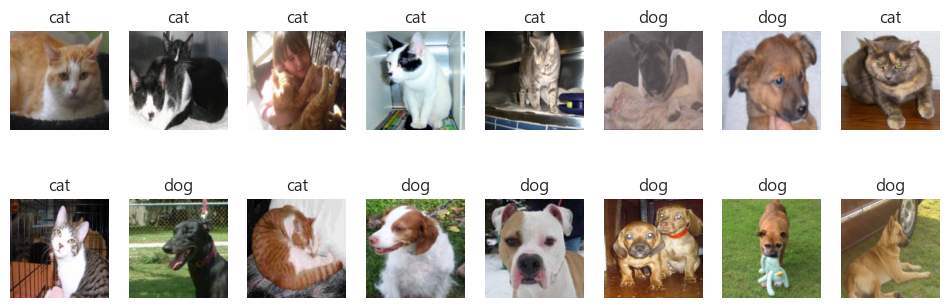

In [ ]:
# 시각화
plt.figure(figsize=(12, 4))
for i in range(16): # 32개 중 반만 표현
    plt.subplot(2, 8, i + 1)

    img = images[i].permute(1, 2, 0) # 컬러채널이기 때문에 matplotlib 표현시 순서 변경
    plt.imshow(img)
    plt.title(f'{class_names[labels[i].item()]}')
    plt.axis('off')

plt.tight_layout
plt.show()
# plt.title('Cats-vs-Dogs train_loader')

#### CNN 모델정의

In [61]:
# 사용모듈 로드
import torch
import torch.nn as nn
import torch.nn.functional as F

In [78]:
# 클래스 정의
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # conv1, conv2 모두 사용
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 32 * 32, 128) # MaxPool(128) -> MaxPool(64) -> 32x32
        self.fc2 = nn.Linear(128, 1) # 마지막 분류가 0, 1

    def forward(self, x):
        # conv -> activation -> maxpooling 2회 실시
        # dense1, 2 통과
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x)) 
        return x

#### 훈련

In [79]:
# cuda 준비
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CatDogCNN().to(device)
criterion = nn.BCELoss() # Binary Cross Entropy 손실함수
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [80]:
# 훈련함수
def train(model, loader, criterion, optimizer):
    model.train() # 훈련모드
    total_loss = 0 
    for images, labels in loader:
        images, labels = images.to(device), labels.float().to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    return total_loss / len(loader)

In [82]:
# 훈련
EPOCH = 20
for epoch in range(EPOCH):
    loss = train(model, train_loader, criterion, optimizer)
    print(f'[{epoch+1}/{EPOCH}] Loss: {loss:.4f}')

[1/20] Loss: 0.0502
[2/20] Loss: 0.0301
[3/20] Loss: 0.0150
[4/20] Loss: 0.0083
[5/20] Loss: 0.0041
[6/20] Loss: 0.0022
[7/20] Loss: 0.0016
[8/20] Loss: 0.0013
[9/20] Loss: 0.0011
[10/20] Loss: 0.0009
[11/20] Loss: 0.0007
[12/20] Loss: 0.0006
[13/20] Loss: 0.0005
[14/20] Loss: 0.0005
[15/20] Loss: 0.0004
[16/20] Loss: 0.0004
[17/20] Loss: 0.0003
[18/20] Loss: 0.0003
[19/20] Loss: 0.0003
[20/20] Loss: 0.0002


#### 예측결과 시각화

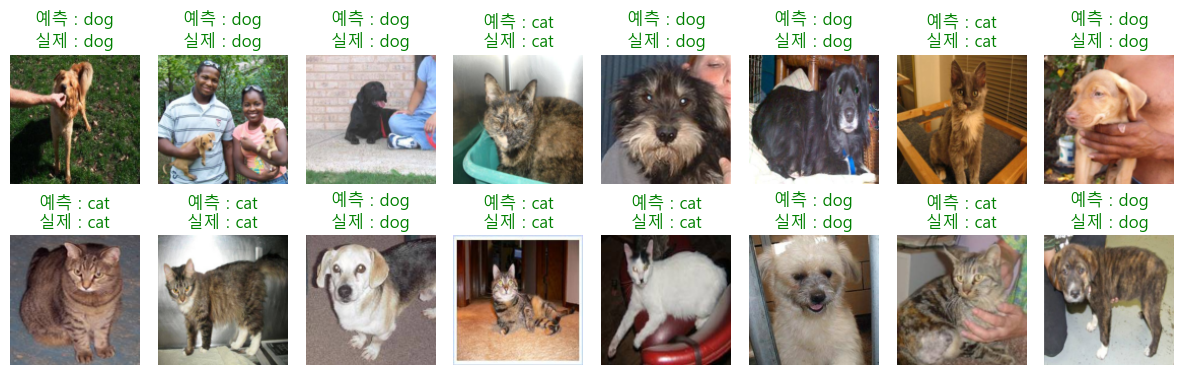

In [97]:
# 검증
model.eval()
images, labels = next(iter(train_loader))
images = images.to(device)
with torch.no_grad() : 
    outputs = model(images)
    preds = (outputs > 0.5).int().cpu().squeeze()

plt.figure(figsize=(12, 4))
for i in range(16) :
    plt.subplot(2, 8, i+1)
    plt.imshow(images[i].cpu().permute(1, 2, 0))
    pred_label = 'dog' if preds[i] == 1 else 'cat'
    true_label = 'dog' if labels[i] == 1 else 'cat'
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f'예측 : {pred_label}\n실제 : {true_label}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

#### 모델 저장 / 불러오기

In [101]:
# 가중치만 저장
torch.save(model.state_dict(), './catdog_weight.pth')

In [102]:
# 모델전체 저장
torch.save(model, './catdog_model.pth')

In [103]:
# 가중치만 불러올 때
model2 = CatDogCNN().to(device)
model2.load_state_dict(torch.load('./catdog_weight.pth', map_location=device))
model2

CatDogCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

#### 테스트 이미지로 테스트
- 1.jpg ~ 12500.jpg 까지 Dog, Cat 구분

In [105]:
# 필요 모듈로드
import torch
from torchvision import transforms
from PIL import Image

In [120]:
# transform 위 선언

img = Image.open('./data/test/15.jpg').convert('RGB')
img_tensor = transforms(img).unsqueeze(0)    # [3, 128, 128] -> [1, 3, 128, 128] 4차원 텐서로 변경
print(img_tensor)
img.show()  # 기본 이미지뷰 프로그램으로 표현

tensor([[[[0.8902, 0.8353, 0.8353,  ..., 0.5765, 0.6314, 0.6314],
          [0.8980, 0.8471, 0.9059,  ..., 0.5961, 0.6706, 0.6353],
          [0.8863, 0.8706, 0.8667,  ..., 0.6039, 0.6196, 0.6196],
          ...,
          [0.7412, 0.7412, 0.7608,  ..., 0.6157, 0.6235, 0.5843],
          [0.7412, 0.7725, 0.7804,  ..., 0.6196, 0.6118, 0.6039],
          [0.7569, 0.7765, 0.7843,  ..., 0.5647, 0.6000, 0.5882]],

         [[0.8471, 0.7922, 0.8000,  ..., 0.5686, 0.6196, 0.6118],
          [0.8510, 0.8078, 0.8667,  ..., 0.5843, 0.6588, 0.6157],
          [0.8392, 0.8314, 0.8314,  ..., 0.5961, 0.6078, 0.6000],
          ...,
          [0.6980, 0.6980, 0.7176,  ..., 0.5725, 0.5765, 0.5373],
          [0.6980, 0.7294, 0.7412,  ..., 0.5725, 0.5608, 0.5569],
          [0.7176, 0.7451, 0.7529,  ..., 0.5216, 0.5529, 0.5373]],

         [[0.7412, 0.6902, 0.7020,  ..., 0.4667, 0.5137, 0.4980],
          [0.7451, 0.7020, 0.7725,  ..., 0.4824, 0.5529, 0.5020],
          [0.7333, 0.7255, 0.7333,  ..., 0

In [118]:
model

CatDogCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [122]:
model.eval()    # 예측, 평가 모드로

with torch.no_grad():
    output = model(img_tensor.to(device))
    pred = (output > 0.5).int().item()

'Dog' if pred == 1 else 'Cat'

'Dog'

#### 폴더로 여러개 테스트

In [127]:
# 파이썬 모듈로드
import os, shutil, random

In [ ]:
test_dir = './data/test'
image_files = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png'))]

In [130]:
len(image_files)

12500

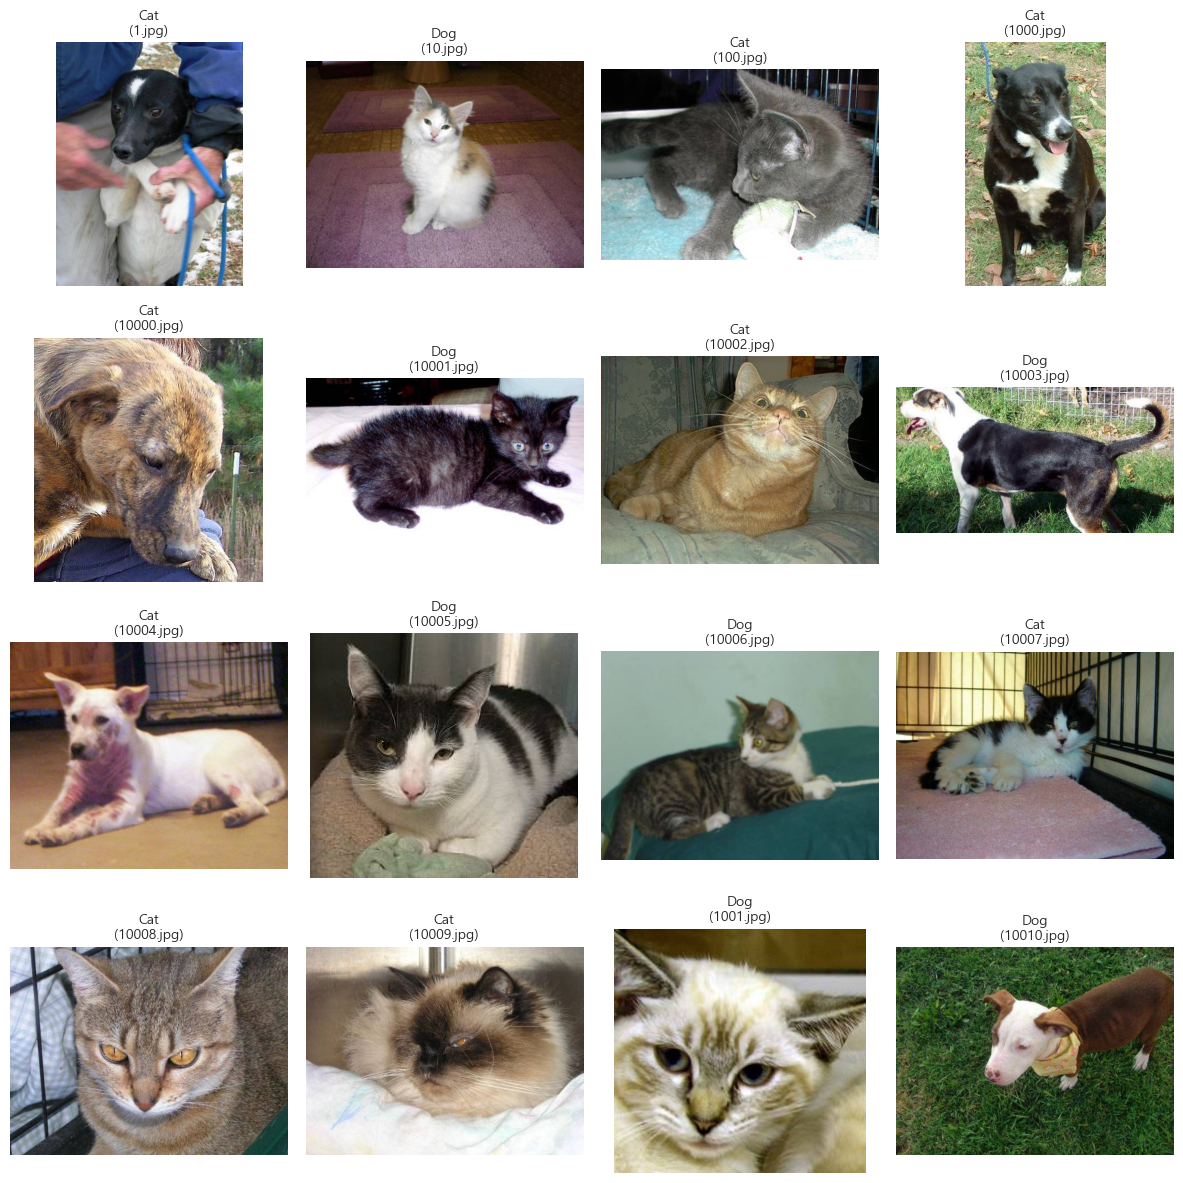

In [137]:
# 예측과 시각화 동시
plt.figure(figsize=(12, 12))
for i, fname in enumerate(image_files[0:16]):
    img_path = os.path.join(test_dir, fname)
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred = 'Dog' if output.item() > 0.5 else 'Cat'
    
    # 이미지 출력
    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(f'{pred}\n({fname})', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Kaggle Competitions 도전

- 캐글상에선 경로 등이 윈도우와 다르기 때문에 설정 변경이 필요함

#### 캐글 순서

1. Data > Join the Competition
2. Code > New Notbook 클릭(코랩과 동일)
3. 노트북 작성
4. 캐글 서버 내 압축파일 처리 부분만 새로 코딩
5. 위의 소스 그대로 사용 가능
6. submission.csv 만드는 코드 추가
7. submission.csv 제출

#### 캐글 GPU

- 캐글 노트북 Settings > Accelerator > GPU T4 x2, GPU P01000 으로 GPU 사용 가능(1주 30시간 제한)